# 01 — Data Preparation & Demand Segmentation

This notebook loads the sample weekly demand data, classifies each material into
a demand pattern (high runner / regular mover / lumpy / sporadic / MTO), and
saves the segmented dataset for the forecasting notebook.

**Note:** This repo uses synthetic sample data generated by `scripts/generate_sample_data.py`.
The structure mirrors a real production pipeline; the underlying numbers are fabricated.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (10, 4)


## Load data

In [2]:
demand = pd.read_csv("../data/sample/weekly_demand.csv", parse_dates=["week_start"])
materials = pd.read_csv("../data/sample/material_master.csv")
stock = pd.read_csv("../data/sample/stock_snapshot.csv")

print(f"Demand rows: {len(demand):,}")
print(f"Materials: {materials['material'].nunique()}")
demand.head()


Demand rows: 6,240
Materials: 60


,material,week_start,shipped_qty
0,SAMPLE-MAT-0001,2024-01-07,605
1,SAMPLE-MAT-0001,2024-01-14,572
2,SAMPLE-MAT-0001,2024-01-21,545
3,SAMPLE-MAT-0001,2024-01-28,506
4,SAMPLE-MAT-0001,2024-02-04,522


## Segmentation logic

Each material is classified using three signals computed over its full history:

- **avg_total_wk** — average weekly shipped quantity
- **demand_fill_rate** — share of weeks with non-zero demand
- **zero_week_pct** — share of weeks with zero demand

A material qualifies as a **True High Runner** when volume is high *and* demand
is consistent (not sparse). Everything else is bucketed by how sparse and how
variable its demand is.


In [3]:
agg = demand.groupby("material")["shipped_qty"].agg(
    avg_total_wk="mean",
    std_wk="std",
    nonzero_weeks=lambda s: (s > 0).sum(),
    total_weeks="count",
).reset_index()

agg["demand_fill_rate"] = agg["nonzero_weeks"] / agg["total_weeks"]
agg["zero_week_pct"] = 1 - agg["demand_fill_rate"]
agg["cv"] = agg["std_wk"] / agg["avg_total_wk"].replace(0, np.nan)

vol_p75 = agg["avg_total_wk"].quantile(0.75)


def classify(row):
    if (
        row["avg_total_wk"] >= vol_p75
        and row["demand_fill_rate"] >= 0.60
        and row["zero_week_pct"] <= 0.35
    ):
        return "true_high_runner"
    elif row["zero_week_pct"] >= 0.85:
        return "mto_intermittent"
    elif row["zero_week_pct"] >= 0.5:
        return "sporadic_high_vol" if row["avg_total_wk"] >= vol_p75 else "lumpy"
    else:
        return "regular_mover"


agg["predicted_segment"] = agg.apply(classify, axis=1)
agg = agg.merge(materials[["material", "segment"]], on="material")
agg.rename(columns={"segment": "true_segment"}, inplace=True)
agg.head(10)


,material,avg_total_wk,std_wk,nonzero_weeks,total_weeks,demand_fill_rate,zero_week_pct,cv,predicted_segment,true_segment
0,SAMPLE-MAT-0001,548.942308,157.674042,104,104,1.000000,0.000000,0.287232,regular_mover,high_runner
1,SAMPLE-MAT-0002,2029.192308,573.348622,104,104,1.000000,0.000000,0.282550,true_high_runner,high_runner
2,SAMPLE-MAT-0003,382.509615,790.783021,24,104,0.230769,0.769231,2.067355,lumpy,sporadic
3,SAMPLE-MAT-0004,193.980769,706.985327,8,104,0.076923,0.923077,3.644616,mto_intermittent,mto
4,SAMPLE-MAT-0005,1170.423077,251.419569,104,104,1.000000,0.000000,0.214811,true_high_runner,regular_mover
5,SAMPLE-MAT-0006,163.528846,529.350930,10,104,0.096154,0.903846,3.237049,mto_intermittent,mto
6,SAMPLE-MAT-0007,166.086538,350.295385,24,104,0.230769,0.769231,2.109114,lumpy,sporadic
7,SAMPLE-MAT-0008,56.605769,227.417260,7,104,0.067308,0.932692,4.017563,mto_intermittent,mto
8,SAMPLE-MAT-0009,1788.182692,340.327677,104,104,1.000000,0.000000,0.190320,true_high_runner,regular_mover
9,SAMPLE-MAT-0010,122.221154,493.434171,7,104,0.067308,0.932692,4.037224,mto_intermittent,mto


## Segment distribution

In [4]:
segment_summary = (
    agg.groupby("predicted_segment")
    .agg(parts=("material", "count"), total_volume=("avg_total_wk", "sum"))
    .assign(pct_volume=lambda d: (d["total_volume"] / d["total_volume"].sum() * 100).round(1))
    .sort_values("pct_volume", ascending=False)
)
segment_summary


,parts,total_volume,pct_volume
predicted_segment,,,
true_high_runner,10,16265.509615,41.6
lumpy,19,7271.375000,18.6
regular_mover,11,7080.750000,18.1
sporadic_high_vol,5,5614.923077,14.4
mto_intermittent,15,2851.855769,7.3


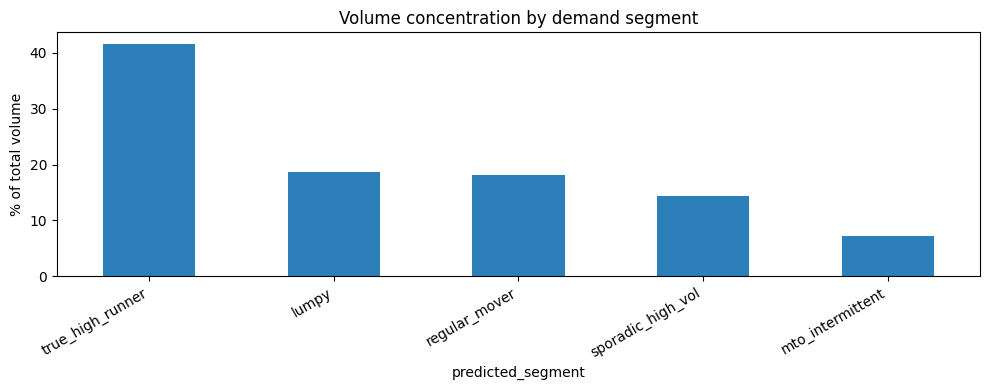

In [5]:
fig, ax = plt.subplots()
segment_summary["pct_volume"].plot(kind="bar", ax=ax, color="#2c7fb8")
ax.set_ylabel("% of total volume")
ax.set_title("Volume concentration by demand segment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/segment_volume_distribution.png", dpi=120)
plt.show()


## Save segmented output

This feeds directly into `02_xgboost_forecasting.ipynb`, which trains a model
only on the high-runner segment.


In [6]:
import os
os.makedirs("../outputs", exist_ok=True)
agg.to_csv("../outputs/material_segmentation.csv", index=False)
print("Saved outputs/material_segmentation.csv")


Saved outputs/material_segmentation.csv
